In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import ast
import os

In [2]:
BASE_PATH = 'dataset'
OUTPUT_PIPELINE = os.path.join(BASE_PATH, 'output_pipeline')
METRICS_FOLDER = os.path.join(OUTPUT_PIPELINE, 'metrics_model_comparison')
LR = os.path.join(OUTPUT_PIPELINE, "linear_regression")
RF = os.path.join(OUTPUT_PIPELINE, 'random_forest')
XGB = os.path.join(OUTPUT_PIPELINE, 'xgboost')

os.makedirs(METRICS_FOLDER, exist_ok=True)

In [3]:
lr_metrics = pd.read_csv(os.path.join(LR, "linear_regression_metrics.csv"))
rf_metrics = pd.read_csv(os.path.join(RF, "random_forest_metrics.csv"))
xgb_metrics = pd.read_csv(os.path.join(XGB, "xgboost_metrics.csv"))

In [4]:
# gabungkan semua metrics
baseline_metrics = pd.concat([
    lr_metrics,
    rf_metrics,
    xgb_metrics,
], ignore_index=True)

print("BASELINE MODEL COMPARISON")
baseline_metrics

BASELINE MODEL COMPARISON


,model,train_mae,train_rmse,train_r2,val_mae,val_rmse,val_r2
0,Linear Regression,"[18681.264085985462, 18241.709600638747, 18221...","[33284.326174225374, 32570.892208577283, 32457...","[0.9766501219482567, 0.9772229614014385, 0.977...","[17167.173117048587, 18764.495694293622, 19021...","[29388.393444422156, 32437.935374718298, 32876...","[0.9804238566399539, 0.9779217105964435, 0.975..."
1,Random Forest,"[4921.397210497482, 4868.303974232365, 5121.78...","[10298.619319553105, 10211.466722802303, 10865...","[0.9977645596366321, 0.9977612056613558, 0.997...","[12276.138874018297, 14362.968086099168, 12885...","[24480.666365841265, 27916.44680887597, 23575....","[0.9864161800573288, 0.9836476831091946, 0.987..."
2,XGBoost,"[6775.615179534054, 6746.718676772786, 6511.34...","[10241.467315062555, 10276.75180217634, 9689.6...","[0.9977557066860406, 0.997700537530526, 0.9980...","[14866.861489934356, 12922.618674494835, 13635...","[33755.52637561623, 21682.829190027092, 23892....","[0.9751318679280491, 0.9904124880680321, 0.986..."


In [5]:
kolom_target = "val_rmse"

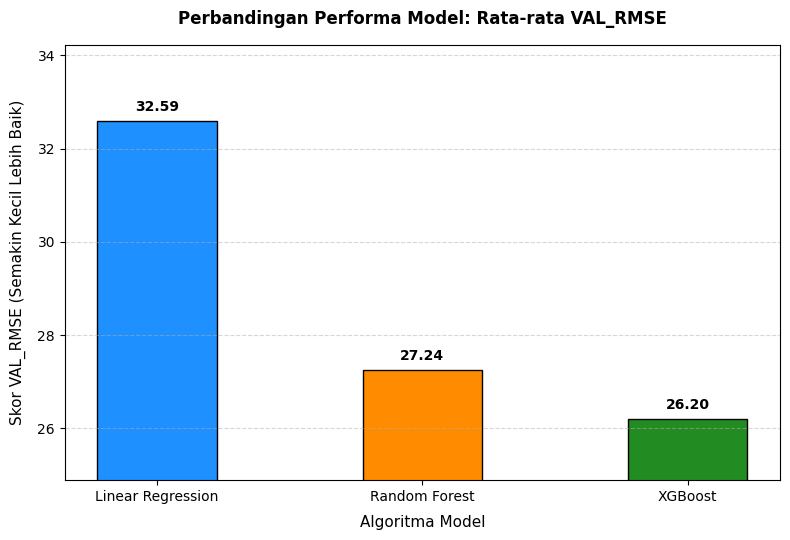

In [6]:
baseline_metrics["plot_value"] = baseline_metrics[kolom_target].apply(
    lambda x: np.mean(ast.literal_eval(x)) / 1000 if isinstance(x, str) else x / 1000
)

fig, ax = plt.subplots(figsize=(8, 5.5))
warna = ["dodgerblue", "darkorange", "forestgreen"]

bars = ax.bar(
    baseline_metrics["model"], 
    baseline_metrics["plot_value"], 
    color=warna, edgecolor="black", width=0.45
)

ax.bar_label(bars, fmt='%.2f', padding=5, fontweight='bold', fontsize=10)

ax.set_title(f"Perbandingan Performa Model: Rata-rata {kolom_target.upper()}", fontsize=12, fontweight="bold", pad=15)
ax.set_ylabel(f"Skor {kolom_target.upper()} (Semakin Kecil Lebih Baik)", fontsize=11, labelpad=8)
ax.set_xlabel("Algoritma Model", fontsize=11, labelpad=8)

ymin, ymax = baseline_metrics["plot_value"].min(), baseline_metrics["plot_value"].max()
ax.set_ylim(ymin * 0.95, ymax * 1.05)

ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(
    os.path.join(METRICS_FOLDER, "model_comparison.png"),
    dpi=300, 
    bbox_inches='tight'
)
plt.show()

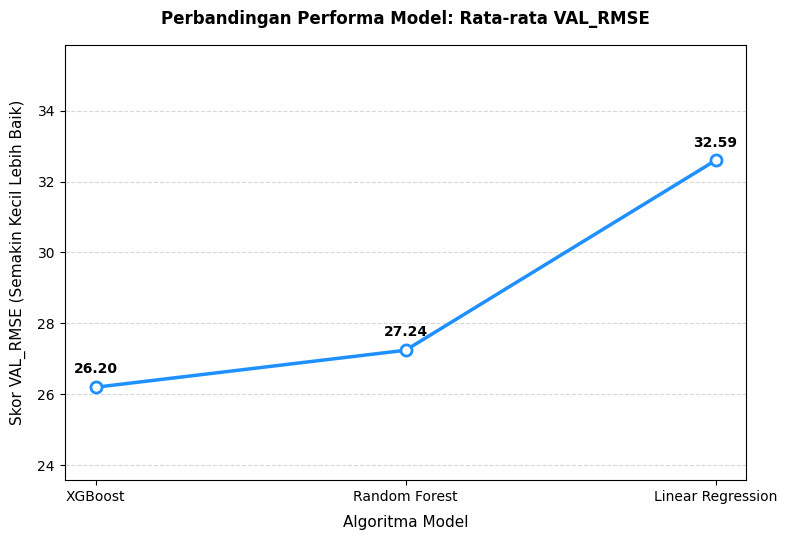

In [8]:
df_plot = baseline_metrics.sort_values(by="plot_value")

fig, ax = plt.subplots(figsize=(8, 5.5))

ax.plot(
    df_plot["model"], 
    df_plot["plot_value"], 
    marker='o',
    linestyle='-',
    color='dodgerblue', 
    linewidth=2.5, 
    markersize=8, 
    markerfacecolor='white', 
    markeredgewidth=2
)

for i, txt in enumerate(df_plot["plot_value"]):
    ax.annotate(f'{txt:.2f}', 
                (df_plot["model"].iloc[i], df_plot["plot_value"].iloc[i]), 
                textcoords="offset points", 
                xytext=(0, 10), 
                ha='center', 
                fontweight='bold', 
                fontsize=10)

ax.set_title(f"Perbandingan Performa Model: Rata-rata {kolom_target.upper()}", fontsize=12, fontweight="bold", pad=15)
ax.set_ylabel(f"Skor {kolom_target.upper()} (Semakin Kecil Lebih Baik)", fontsize=11, labelpad=8)
ax.set_xlabel("Algoritma Model", fontsize=11, labelpad=8)

ymin, ymax = df_plot["plot_value"].min(), df_plot["plot_value"].max()
ax.set_ylim(ymin * 0.9, ymax * 1.1)

ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(
    os.path.join(METRICS_FOLDER, "model_comparison_line_chart.png"),
    dpi=300, 
    bbox_inches='tight'
)
plt.show()

In [48]:
# simpan hasil akhir
baseline_metrics.to_csv(
    os.path.join(METRICS_FOLDER, 'baseline_metrics_comparison.csv'),
    index=False
)

print("Berkas berhasil disimpan!")

Berkas berhasil disimpan!
